In [1]:
from importlib import reload

import nflreadpy as nfl
import pathlib
import polars as pl
import numpy as np

from lib import data_processing_utils as data_utils
from lib import best_subset_utils as bs_utils
from lib import plotting_utils
from lib import file_utils as futils

In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
#Shared variables
beginning_season = 1999
end_season = 2025

In [9]:
combined_data = data_utils.get_combined_data(beginning_season, end_season)

# for column in combined_data.columns:
#     print(f"Column: {column} | Dtype: {combined_data[column].dtype}")

combined_data = combined_data.sort('id')
combined_data = data_utils.add_fantasy_scoring(combined_data)
combined_data = data_utils.add_season_aggregate_stats(combined_data, ['num_games'])
combined_data = data_utils.add_ranking_column(combined_data, ranking_col='class_ppr_score', new_col_name='class_ppr_ranking', group_cols=['season'])
combined_data = data_utils.add_ranking_column(combined_data, ranking_col='class_ppr_score', new_col_name='class_ppr_ranking_position', group_cols=['season', 'position'])

combined_data = data_utils.add_position_group_ranking_columns(combined_data)

# combined_data_result = data_utils.collect_and_print_profile(combined_data)


shape: (18, 4)
┌─────────────────────────────────┬───────┬───────┬─────────────┐
│ node                            ┆ start ┆ end   ┆ duration_ms │
│ ---                             ┆ ---   ┆ ---   ┆ ---         │
│ str                             ┆ u64   ┆ u64   ┆ u64         │
╞═════════════════════════════════╪═══════╪═══════╪═════════════╡
│ optimization                    ┆ 0     ┆ 2055  ┆ 2055        │
│ .filter(col("position").is_in(… ┆ 2054  ┆ 4100  ┆ 2046        │
│ .filter(col("Season").alias("s… ┆ 2055  ┆ 2151  ┆ 96          │
│ with_column(position, player_i… ┆ 2059  ┆ 4055  ┆ 1996        │
│ select(season, num_games)       ┆ 2153  ┆ 2190  ┆ 37          │
│ simple-projection(num_games, s… ┆ 2190  ┆ 2192  ┆ 2           │
│ simple-projection(player_id, p… ┆ 4056  ┆ 4064  ┆ 8           │
│ select(player_id, player_displ… ┆ 4111  ┆ 5530  ┆ 1419        │
│ with_column(games, def_sacks, … ┆ 5539  ┆ 7451  ┆ 1912        │
│ select(player_id, player_displ… ┆ 7790  ┆ 10601 ┆ 2811     

In [12]:

combined_data_with_future_scores=data_utils.shift_column_by_season(
    combined_data,
    'class_ppr_score',
    shift=-1,
    id_col='id',
)

combined_data_with_future_scores = data_utils.add_log_column(combined_data_with_future_scores, 'class_ppr_score')
combined_data_with_future_scores = data_utils.add_log_column(combined_data_with_future_scores, 'future_class_ppr_score')

# data_utils.debug_pipeline(combined_data_with_future_scores)

combined_data_with_future_scores = data_utils.collect_and_print_profile(combined_data_with_future_scores.sort('id'))

for column in combined_data_with_future_scores.columns:
    print(f"Column: {column} | Dtype: {combined_data_with_future_scores[column].dtype}")

# combined_data_with_future_scores.sort(pl.col("id"))

shape: (23, 4)
┌─────────────────────────────────┬───────┬───────┬─────────────┐
│ node                            ┆ start ┆ end   ┆ duration_ms │
│ ---                             ┆ ---   ┆ ---   ┆ ---         │
│ str                             ┆ u64   ┆ u64   ┆ f64         │
╞═════════════════════════════════╪═══════╪═══════╪═════════════╡
│ optimization                    ┆ 0     ┆ 4020  ┆ 4.02        │
│ .filter(col("Season").alias("s… ┆ 4020  ┆ 4078  ┆ 0.058       │
│ .filter(col("position").is_in(… ┆ 4022  ┆ 6331  ┆ 2.309       │
│ with_column(position, player_i… ┆ 4025  ┆ 6166  ┆ 2.141       │
│ select(season, num_games)       ┆ 4080  ┆ 4111  ┆ 0.031       │
│ simple-projection(num_games, s… ┆ 4112  ┆ 4113  ┆ 0.001       │
│ simple-projection(player_id, p… ┆ 6168  ┆ 6179  ┆ 0.011       │
│ select(player_id, player_displ… ┆ 6345  ┆ 7398  ┆ 1.053       │
│ with_column(games, def_sacks, … ┆ 7404  ┆ 8394  ┆ 0.99        │
│ select(player_id, player_displ… ┆ 8778  ┆ 11269 ┆ 2.491    

In [21]:
# best subset analysis
# output = bs_utils.exhaustive_best_subset_selection(
#     combined_data_with_future_scores,
#     'log1p_future_class_ppr_score',
#     max_features=10
# )
# (best_features, metrics) = output
#
# print(best_features)
# total tests: 254186856
# k: 1 | best_score: 0.1304462255487019 | best_subset: ('receptions',)
# k: 2 | best_score: 0.2012223673311635 | best_subset: ('passing_tds', 'receptions')
# k: 3 | best_score: 0.26623984983880755 | best_subset: ('passing_yards', 'receptions', 'games')
# k: 4 | best_score: 0.3317475160469834 | best_subset: ('passing_yards', 'receptions', 'fg_made', 'games')
# k: 5 | best_score: 0.37742154544256257 | best_subset: ('passing_yards', 'rushing_yards', 'receiving_yards', 'fg_made', 'games')
# k: 6 | best_score: 0.379141481156997 | best_subset: ('passing_yards', 'rushing_yards', 'receptions', 'receiving_yards', 'fg_made', 'games')

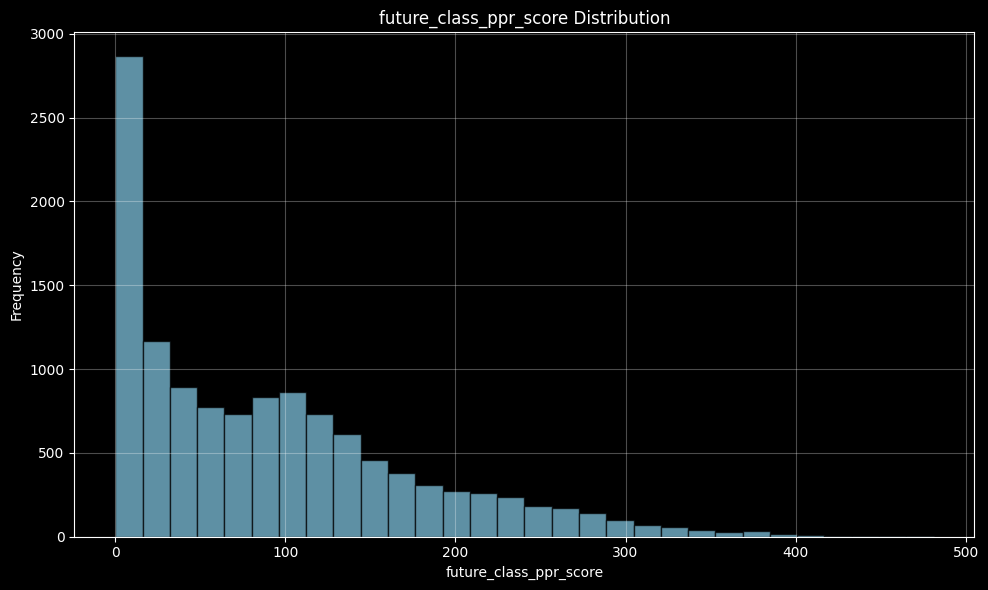

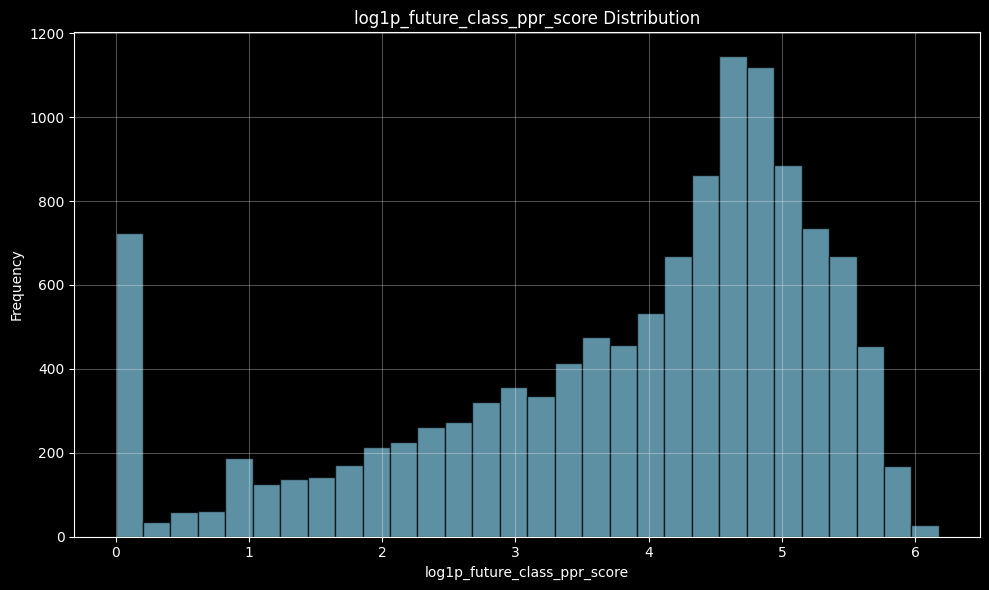

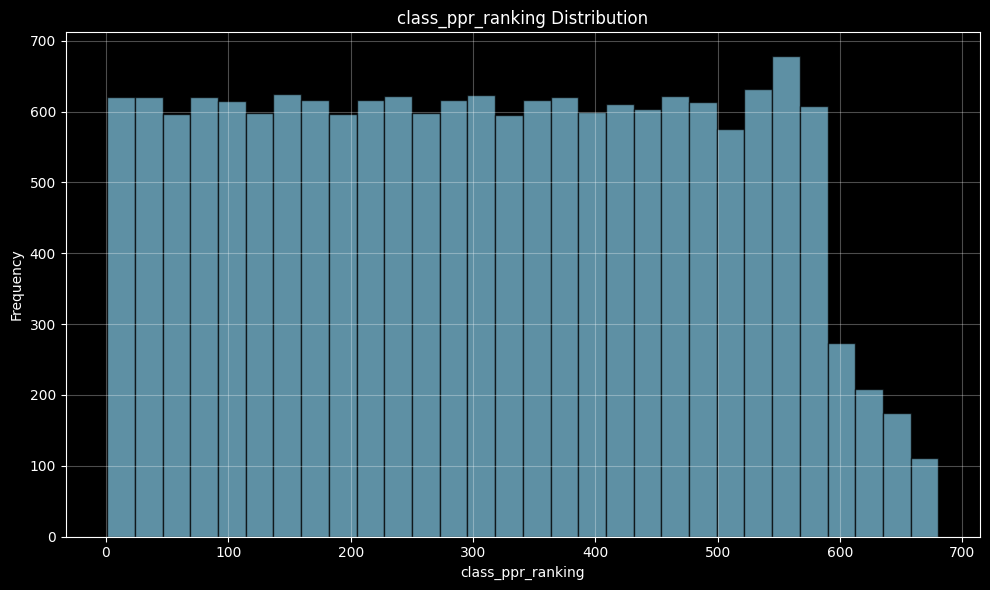

In [14]:
# display a histogram of future_class_ppr_score and log1p_future_class_ppr_score columns
plotting_utils.plot_histogram(combined_data_with_future_scores, 'future_class_ppr_score')
plotting_utils.plot_histogram(combined_data_with_future_scores, 'log1p_future_class_ppr_score')

plotting_utils.plot_histogram(combined_data_with_future_scores, 'class_ppr_ranking')

In [15]:
# prepare output
name = f"combined_data_with_future_scores_{beginning_season}_{end_season}"

In [16]:
futils.output_result_frame(combined_data_with_future_scores, name)

None
